## <span style="color:red">All imports and configuration live here</span>
#### Changing anything here WILL break stuff. It is discouraged unless you understand what's going on. Also, try not moving files or folders around.

In [1]:
%pip install -e "../..[mmd]"

Obtaining file:///Users/fuzi_x_muzi/Documents/PoliTech%20Research/Politech-Fair-Representation-Act
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fair-representation-act (pyproject.toml) ... done
  Created wheel for fair-representation-act: filename=fair_representation_act-0.1.0-0.editable-py3-none-any.whl size=9341 sha256=e223ef033b942072a0c5a940b57e768363fa9ea38b7b4970fd5cfc4647ebc0b5
  Stored in directory: /private/var/folders/34/k7nfgbcn10qfj_089s0jtbs40000gn/T/pip-ephem-wheel-cache-gaby9yyl/wheels/78/38/07/f50c7b1a22226fc8642bb0b1c5ebc328f7c45d8d16ff6e904a
Successfully built fair-representation-act
  Attempting uninstall: fair-representation-act
    Found existing installation: fair-representation-act 0.1.0
    Can't uninstall 'fair-representation-act'. No files were found to uninstall.

[notice] A 

In [2]:
import random
import json
import importlib
from MMD_Generation_Layer import config
import shutil
import os

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from functools import partial

from gerrychain import Graph, Partition, MarkovChain
from gerrychain.updaters import Tally
from gerrychain.tree import recursive_tree_part
from gerrychain.accept import always_accept
from gerrychain.proposals import recom
from gerrychain.constraints import within_percent_of_ideal_population, contiguous

from collections import defaultdict, deque
import sys

In [3]:
# Shared config import
importlib.reload(config)
from MMD_Generation_Layer.config import (
    processor_dir,
    base_dir,
    shape_path,
    output_dir,
    plans_dir,
    ensemble_csv_path,
    seat_share_png_path,
    NUM_PLANS,
    NUM_DISTRICTS,
    ID_COLUMN,
    GEOM_COLUMN,
    SEED
)

In [4]:
# !rm -rf output_dir

In [5]:
# Runtime mutable state and run controls
GDF = None

# Defaults sourced from config.py (plus notebook-only controls).
RUN_DEFAULTS = {
    "generation_mode": "SMD",
    "num_plans": NUM_PLANS,
    "num_districts": NUM_DISTRICTS,
    "seed": SEED,
    "shape_path": str(shape_path),
    "id_column": ID_COLUMN,
    "geom_column": GEOM_COLUMN,
    "seat_vector": [4, 5, 5],
    "mmd_smd_multiplier": 10,
    "mmd_plans_per_smd_plan": 5,
    "population_tolerance": 0.05,
    "max_mmd_attempts_per_smd_plan": 250,
}

# High-level generation mode: "SMD" or "MMD"
GENERATION_MODE = RUN_DEFAULTS["generation_mode"]

# Core run controls (can be overridden via config files)
RUN_NUM_PLANS = RUN_DEFAULTS["num_plans"]
RUN_NUM_DISTRICTS = RUN_DEFAULTS["num_districts"]
RUN_SEED = RUN_DEFAULTS["seed"]
RUN_SHAPE_PATH = RUN_DEFAULTS["shape_path"]
RUN_ID_COLUMN = RUN_DEFAULTS["id_column"]
RUN_GEOM_COLUMN = RUN_DEFAULTS["geom_column"]

# Seat vector only used in MMD mode (example: [3, 3, 4, 5, 5])
MMD_SEAT_VECTOR = list(RUN_DEFAULTS["seat_vector"])

# MMD-mode generation controls
MMD_SMD_MULTIPLIER = RUN_DEFAULTS["mmd_smd_multiplier"]
MMD_PLANS_PER_SMD_PLAN = RUN_DEFAULTS["mmd_plans_per_smd_plan"]
POPULATION_TOLERANCE = RUN_DEFAULTS["population_tolerance"]
MAX_MMD_ATTEMPTS_PER_SMD_PLAN = RUN_DEFAULTS["max_mmd_attempts_per_smd_plan"]

# Optional notebook run config JSON.
# Example: "../Tests/Notebook_Run_Configs/mmd_valid_balanced.json"
CONFIG_PATH = "../Tests/Notebook_Run_Configs/mmd_edge_low_attempt_budget.json"


In [6]:
RUN_CONFIG_ALLOWED_KEYS = {
    "generation_mode",
    "num_plans",
    "num_districts",
    "seed",
    "shape_path",
    "id_column",
    "geom_column",
    "population_tolerance",
    "seat_vector",
    "mmd_seat_vector",
    "mmd_smd_multiplier",
    "mmd_plans_per_smd_plan",
    "max_mmd_attempts_per_smd_plan",
    "expected_behavior",
    "notes",
}


def _resolve_run_config_path(config_path):
    """Resolve config path against common notebook roots."""
    raw_path = Path(config_path).expanduser()
    candidates = [raw_path]

    if not raw_path.is_absolute():
        candidates.append(processor_dir / raw_path)
        candidates.append(base_dir / raw_path)

    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate.resolve()

    attempted = ", ".join(str(c) for c in candidates)
    raise FileNotFoundError(f"Could not find config file. Tried: {attempted}")


def _validate_positive_int_list(name, value):
    """Validate a non-empty list of positive ints."""
    if not isinstance(value, list) or len(value) == 0:
        raise ValueError(f"{name} must be a non-empty list")
    if any((not isinstance(s, int)) or s <= 0 for s in value):
        raise ValueError(f"{name} must contain only positive integers")


def _extract_seat_vector_from_config(config):
    """Return validated seat vector from config or None if omitted."""
    if "mmd_seat_vector" in config:
        raise ValueError(
            "mmd_seat_vector is no longer supported; use seat_vector"
        )

    if "seat_vector" not in config:
        return None

    _validate_positive_int_list("seat_vector", config["seat_vector"])
    return list(config["seat_vector"])


def _validate_run_config(config):
    """Validate configuration content before applying notebook globals."""
    unknown_keys = sorted(set(config) - RUN_CONFIG_ALLOWED_KEYS)
    if unknown_keys:
        raise ValueError(f"Unsupported config keys: {unknown_keys}")

    mode = str(config.get("generation_mode", GENERATION_MODE)).strip().upper()
    if mode not in {"SMD", "MMD"}:
        raise ValueError("generation_mode must be 'SMD' or 'MMD'")

    for key in [
        "num_plans",
        "num_districts",
        "seed",
        "mmd_smd_multiplier",
        "mmd_plans_per_smd_plan",
        "max_mmd_attempts_per_smd_plan",
    ]:
        if key in config:
            value = config[key]
            if not isinstance(value, int) or value <= 0:
                raise ValueError(f"{key} must be a positive integer")

    if "population_tolerance" in config:
        tolerance = config["population_tolerance"]
        if not isinstance(tolerance, (int, float)):
            raise ValueError("population_tolerance must be numeric")
        if tolerance <= 0 or tolerance >= 1:
            raise ValueError("population_tolerance must be between 0 and 1 (exclusive)")

    resolved_seat_vector = _extract_seat_vector_from_config(config)

    if mode == "MMD":
        effective_seat_vector = resolved_seat_vector if resolved_seat_vector is not None else MMD_SEAT_VECTOR
        if not effective_seat_vector:
            raise ValueError("seat_vector is required when generation_mode is 'MMD'")

        effective_num_districts = int(config.get("num_districts", RUN_NUM_DISTRICTS))
        effective_total_seats = sum(int(s) for s in effective_seat_vector)

        if effective_total_seats != effective_num_districts:
            raise ValueError(
                "MMD seat-vector sum mismatch: "
                f"sum(seat_vector)={effective_total_seats} "
                f"but num_districts={effective_num_districts}"
            )


def reset_run_globals_to_defaults():
    """Reset runtime globals to notebook defaults sourced from config.py."""
    global GENERATION_MODE
    global RUN_NUM_PLANS, RUN_NUM_DISTRICTS, RUN_SEED
    global RUN_SHAPE_PATH, RUN_ID_COLUMN, RUN_GEOM_COLUMN
    global POPULATION_TOLERANCE
    global MMD_SEAT_VECTOR, MMD_SMD_MULTIPLIER, MMD_PLANS_PER_SMD_PLAN
    global MAX_MMD_ATTEMPTS_PER_SMD_PLAN

    GENERATION_MODE = RUN_DEFAULTS["generation_mode"]
    RUN_NUM_PLANS = RUN_DEFAULTS["num_plans"]
    RUN_NUM_DISTRICTS = RUN_DEFAULTS["num_districts"]
    RUN_SEED = RUN_DEFAULTS["seed"]
    RUN_SHAPE_PATH = RUN_DEFAULTS["shape_path"]
    RUN_ID_COLUMN = RUN_DEFAULTS["id_column"]
    RUN_GEOM_COLUMN = RUN_DEFAULTS["geom_column"]
    POPULATION_TOLERANCE = RUN_DEFAULTS["population_tolerance"]
    MMD_SEAT_VECTOR = list(RUN_DEFAULTS["seat_vector"])
    MMD_SMD_MULTIPLIER = RUN_DEFAULTS["mmd_smd_multiplier"]
    MMD_PLANS_PER_SMD_PLAN = RUN_DEFAULTS["mmd_plans_per_smd_plan"]
    MAX_MMD_ATTEMPTS_PER_SMD_PLAN = RUN_DEFAULTS["max_mmd_attempts_per_smd_plan"]


def apply_run_config(config):
    """Apply validated run config values to notebook runtime globals."""
    global GENERATION_MODE
    global RUN_NUM_PLANS, RUN_NUM_DISTRICTS, RUN_SEED
    global RUN_SHAPE_PATH, RUN_ID_COLUMN, RUN_GEOM_COLUMN
    global POPULATION_TOLERANCE
    global MMD_SEAT_VECTOR, MMD_SMD_MULTIPLIER, MMD_PLANS_PER_SMD_PLAN
    global MAX_MMD_ATTEMPTS_PER_SMD_PLAN

    _validate_run_config(config)

    GENERATION_MODE = str(config.get("generation_mode", GENERATION_MODE)).strip().upper()
    RUN_NUM_PLANS = int(config.get("num_plans", RUN_NUM_PLANS))
    RUN_NUM_DISTRICTS = int(config.get("num_districts", RUN_NUM_DISTRICTS))
    RUN_SEED = int(config.get("seed", RUN_SEED))
    RUN_SHAPE_PATH = str(config.get("shape_path", RUN_SHAPE_PATH))
    RUN_ID_COLUMN = str(config.get("id_column", RUN_ID_COLUMN))
    RUN_GEOM_COLUMN = str(config.get("geom_column", RUN_GEOM_COLUMN))
    POPULATION_TOLERANCE = float(config.get("population_tolerance", POPULATION_TOLERANCE))

    resolved_seat_vector = _extract_seat_vector_from_config(config)
    if resolved_seat_vector is not None:
        MMD_SEAT_VECTOR = [int(s) for s in resolved_seat_vector]

    MMD_SMD_MULTIPLIER = int(config.get("mmd_smd_multiplier", MMD_SMD_MULTIPLIER))
    MMD_PLANS_PER_SMD_PLAN = int(config.get("mmd_plans_per_smd_plan", MMD_PLANS_PER_SMD_PLAN))
    MAX_MMD_ATTEMPTS_PER_SMD_PLAN = int(
        config.get("max_mmd_attempts_per_smd_plan", MAX_MMD_ATTEMPTS_PER_SMD_PLAN)
    )

    print("✅ Applied run config")
    print(f"   generation_mode: {GENERATION_MODE}")
    print(f"   num_plans: {RUN_NUM_PLANS}")
    print(f"   num_districts: {RUN_NUM_DISTRICTS}")
    print(f"   seed: {RUN_SEED}")
    print(f"   population_tolerance: {POPULATION_TOLERANCE}")
    print(f"   seat_vector: {MMD_SEAT_VECTOR}")


def load_run_config(config_path):
    """Load JSON config from disk and apply to runtime globals."""
    resolved_path = _resolve_run_config_path(config_path)

    with open(resolved_path, "r") as f:
        config = json.load(f)

    apply_run_config(config)
    print(f"   source: {resolved_path}")
    return config


def bootstrap_run_config(config_path=None):
    """
    Initialize run configuration.

    Behavior:
    - Always starts from config.py-backed defaults.
    - If a config path is provided, attempts JSON overrides.
    - If loading/validation fails, warns and continues with defaults.
    """
    reset_run_globals_to_defaults()

    if config_path is None:
        print("ℹ️ CONFIG_PATH not set; using config.py defaults.")
        return None

    config_path = str(config_path).strip()
    if not config_path:
        print("ℹ️ CONFIG_PATH is empty; using config.py defaults.")
        return None

    try:
        return load_run_config(config_path)
    except Exception as exc:
        reset_run_globals_to_defaults()
        print("⚠️ Failed to load run config; continuing with config.py defaults.")
        print(f"   path: {config_path}")
        print(f"   error: {type(exc).__name__}: {exc}")
        return None


_ = bootstrap_run_config(CONFIG_PATH)


✅ Applied run config
   generation_mode: MMD
   num_plans: 100
   num_districts: 14
   seed: 9090
   population_tolerance: 0.05
   seat_vector: [5, 5, 4]
   source: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Tests/Notebook_Run_Configs/mmd_edge_low_attempt_budget.json


## <span style="color:red">Beginning of internal function definitions</span>
#### These functions are the heart of the redistricting algorithm. They currently rely on one shapefile for North Carolina to function. Future abstraction to various states is planned.

#### The <code>load_and_build_graph</code> function builds the graph that represents the voting districts. Each district is a node and each edge shows continuity.

In [7]:
def load_and_build_graph(shape_path=shape_path, id_col=ID_COLUMN, geom_col=GEOM_COLUMN):
    global GDF
    print("=" * 60)
    print("📊 STEP 1: Baseline Ensemble Generation")
    print("=" * 60)

    print("\n📂 Loading shapefile...")
    GDF = gpd.read_file(shape_path)
    print(f"✅ Loaded {len(GDF)} rows.")

    # Ensure geometry column is active
    if geom_col in GDF.columns:
        GDF = GDF.set_geometry(geom_col)

    # Required columns
    required_cols = {
        id_col,
        "TOTPOP",
        "G24PREDHAR",
        "G24PRERTRU",
        GDF.geometry.name
    }

    missing = required_cols - set(GDF.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    # Keep only what we need
    GDF = GDF[list(required_cols)].copy()

    # Normalize ID
    GDF[id_col] = GDF[id_col].astype(str).str.strip()

    if not GDF[id_col].is_unique:
        raise ValueError(f"{id_col} is not unique. Cannot use as node ID.")

    # Ensure numeric types
    GDF["TOTPOP"] = pd.to_numeric(GDF["TOTPOP"], errors="coerce").fillna(0).astype(int)
    GDF["G24PREDHAR"] = pd.to_numeric(GDF["G24PREDHAR"], errors="coerce").fillna(0).astype(int)
    GDF["G24PRERTRU"] = pd.to_numeric(GDF["G24PRERTRU"], errors="coerce").fillna(0).astype(int)

    # Fix invalid geometries
    invalid = ~GDF.geometry.is_valid
    if invalid.any():
        print(f"Repairing {invalid.sum()} invalid geometries...")
        GDF.loc[invalid, "geometry"] = GDF.loc[invalid, "geometry"].buffer(0)

    # Set index BEFORE building graph
    GDF = GDF.set_index(id_col, drop=False)

    print("\n🔨 Building GerryChain dual graph...")
    graph = Graph.from_geodataframe(GDF)

    # Attach attributes
    for node in graph.nodes():
        row = GDF.loc[node]
        graph.nodes[node]["population"] = row["TOTPOP"]
        graph.nodes[node]["votes_dem"] = row["G24PREDHAR"]
        graph.nodes[node]["votes_rep"] = row["G24PRERTRU"]

    # Graph diagnostics
    degrees = [graph.degree(n) for n in graph.nodes()]
    iso = sum(1 for d in degrees if d == 0)

    print(f"✅ Graph built ({len(graph.nodes())} nodes, {len(graph.edges())} edges)")
    print(f"   Isolated nodes: {iso}")
    print(f"   Degree min/median/max: "
          f"{min(degrees)}/{sorted(degrees)[len(degrees)//2]}/{max(degrees)}")

    return graph

#### The <code>create_initial_partition</code> function does some stuff I dont completely understand lmao

In [8]:
def create_initial_partition(
    graph,
    num_districts=NUM_DISTRICTS,
    seed=SEED,
    population_tolerance=0.05,
):
    """
    Create initial contiguous partition using recursive tree partitioning.

    Args:
        graph: GerryChain Graph
        num_districts: Number of districts
        seed: Random seed
        population_tolerance: Allowed population deviation from target

    Returns:
        Partition object
    """
    random.seed(seed)

    print(f"\n🎲 Creating initial partition ({num_districts} districts)...")

    total_population = sum(graph.nodes[n]["population"] for n in graph.nodes())
    ideal_population = total_population / num_districts

    print(f"   Ideal population per district: {ideal_population:,.0f}")
    print(f"   Population tolerance: ±{population_tolerance * 100:.1f}%")
    print("   Using recursive tree partitioning...")

    # Create contiguous initial partition
    assignment = recursive_tree_part(
        graph,
        range(num_districts),
        ideal_population,
        "population",
        population_tolerance,
        1,
    )

    # Create partition with updaters
    partition = Partition(
        graph,
        assignment=assignment,
        updaters={
            "population": Tally("population"),
            "votes_dem": Tally("votes_dem"),
            "votes_rep": Tally("votes_rep"),
        },
    )

    print(f"✅ Initial partition created with {len(partition.parts)} districts.")

    return partition


#### Builds an ensemble of <code>NUM_DISTRICTS</code> different district plans

In [9]:
def generate_baseline_ensemble(
    graph,
    num_plans=NUM_PLANS,
    num_districts=NUM_DISTRICTS,
    seed=42,
    population_tolerance=0.05,
):
    """
    Generate ensemble of random district plans using ReCom.

    Args:
        graph: GerryChain Graph
        num_plans: Number of plans to generate
        num_districts: Number of districts
        seed: Random seed
        population_tolerance: Allowed population deviation from target

    Returns:
        List of plan dictionaries
    """
    print(f"\n⚙️  Setting up ReCom chain to generate {num_plans} plans...")

    # Create initial partition
    initial_partition = create_initial_partition(
        graph,
        num_districts=num_districts,
        seed=seed,
        population_tolerance=population_tolerance,
    )

    # Set up constraints
    population_constraint = within_percent_of_ideal_population(
        initial_partition,
        population_tolerance,
    )

    # Set up ReCom proposal
    total_population = sum(graph.nodes[n]["population"] for n in graph.nodes())
    ideal_pop = total_population / num_districts

    proposal = partial(
        recom,
        pop_col="population",
        pop_target=ideal_pop,
        epsilon=population_tolerance,
        node_repeats=2,
    )

    # Create Markov chain
    chain = MarkovChain(
        proposal=proposal,
        constraints=[contiguous, population_constraint],
        accept=always_accept,
        initial_state=initial_partition,
        total_steps=num_plans,
    )

    # Generate plans
    print(f"\n🚀 Generating {num_plans} random district plans...")
    print("   (This may take a minute...)")

    ensemble = []
    plan_counter = 0

    for partition in chain:
        plan_counter += 1

        # Calculate election results for this plan
        dem_seats = 0
        rep_seats = 0

        for district in partition.parts:
            district_dem = partition["votes_dem"][district]
            district_rep = partition["votes_rep"][district]

            if district_dem > district_rep:
                dem_seats += 1
            else:
                rep_seats += 1

        dem_seat_share = dem_seats / num_districts

        results = {
            "plan_id": plan_counter,
            "dem_seats": dem_seats,
            "rep_seats": rep_seats,
            "dem_seat_share": dem_seat_share,
        }

        # Store partition assignment for visualization
        assignment = dict(partition.assignment)

        ensemble.append(
            {
                "results": results,
                "assignment": assignment,
            }
        )

        if plan_counter % 5 == 0 or plan_counter == num_plans:
            print(f"   ✓ Generated {plan_counter}/{num_plans} plans...")

    print(f"✅ Generated {num_plans} random district plans.")

    return ensemble


#### <code>MMD merge helpers</code> convert temporary SMD plans into unequal-size MMD plans


In [10]:
def _build_smd_unit_stats(smd_assignment, graph):
    """Aggregate node-level graph attributes into per-SMD units."""
    units = {}

    for node_id, district_id in smd_assignment.items():
        smd_id = int(district_id)

        if smd_id not in units:
            units[smd_id] = {
                "nodes": set(),
                "population": 0,
                "votes_dem": 0,
                "votes_rep": 0,
            }

        units[smd_id]["nodes"].add(node_id)
        units[smd_id]["population"] += int(graph.nodes[node_id]["population"])
        units[smd_id]["votes_dem"] += int(graph.nodes[node_id]["votes_dem"])
        units[smd_id]["votes_rep"] += int(graph.nodes[node_id]["votes_rep"])

    return units


def _build_smd_adjacency(smd_assignment, graph):
    """Build adjacency graph where each node is an SMD ID."""
    smd_adjacency = defaultdict(set)

    for district_id in smd_assignment.values():
        smd_adjacency[int(district_id)]

    for node_u, node_v in graph.edges():
        smd_u = int(smd_assignment[node_u])
        smd_v = int(smd_assignment[node_v])

        if smd_u == smd_v:
            continue

        smd_adjacency[smd_u].add(smd_v)
        smd_adjacency[smd_v].add(smd_u)

    return dict(smd_adjacency)


def _find_bfs_merge_candidate(
    start_smd,
    seat_count,
    available_smd_ids,
    smd_adjacency,
    smd_population,
    per_seat_population,
    population_tolerance,
    max_states=20000,
):
    """
    Find a contiguous SMD merge using BFS that matches a seat-weighted population target.

    Returns:
        tuple(set_of_smd_ids, merged_population) or None
    """
    target_population = seat_count * per_seat_population
    lower_bound = target_population * (1 - population_tolerance)
    upper_bound = target_population * (1 + population_tolerance)

    start_state = frozenset([start_smd])
    state_population = {start_state: smd_population[start_smd]}
    queue = deque([start_state])
    visited = {start_state}

    best_state = start_state
    best_deviation = abs(state_population[start_state] - target_population) / target_population

    explored = 0
    while queue and explored < max_states:
        current_state = queue.popleft()
        current_population = state_population[current_state]
        explored += 1

        current_deviation = abs(current_population - target_population) / target_population
        if current_deviation < best_deviation:
            best_state = current_state
            best_deviation = current_deviation

        if lower_bound <= current_population <= upper_bound:
            return set(current_state), current_population

        # Population only increases as we merge, so we can prune oversized states.
        if current_population >= upper_bound:
            continue

        frontier = set()
        for smd_id in current_state:
            frontier.update(smd_adjacency.get(smd_id, set()))

        for neighbor_smd in sorted(frontier):
            if neighbor_smd not in available_smd_ids or neighbor_smd in current_state:
                continue

            new_state = frozenset(set(current_state) | {neighbor_smd})
            if new_state in visited:
                continue

            new_population = current_population + smd_population[neighbor_smd]
            visited.add(new_state)
            state_population[new_state] = new_population
            queue.append(new_state)

    best_population = state_population[best_state]
    best_deviation = abs(best_population - target_population) / target_population

    if best_deviation <= population_tolerance:
        return set(best_state), best_population

    return None


def _validate_mmd_plan(mmd_plan, graph, seat_vector, population_tolerance):
    """Validate full-node coverage, seat accounting, and population bounds."""
    expected_nodes = set(graph.nodes())
    assigned_nodes = set(mmd_plan["assignment"].keys())
    if assigned_nodes != expected_nodes:
        return False, "Not all nodes are mapped in final MMD assignment"

    expected_sorted = sorted(int(s) for s in seat_vector)
    observed_sorted = sorted(int(d["seat_count"]) for d in mmd_plan["district_summaries"])
    if observed_sorted != expected_sorted:
        return False, "MMD seat vector does not match requested seat vector"

    total_population = sum(int(graph.nodes[n]["population"]) for n in graph.nodes())
    total_seats = sum(expected_sorted)
    per_seat_population = total_population / total_seats

    for district_summary in mmd_plan["district_summaries"]:
        target_population = district_summary["seat_count"] * per_seat_population
        observed_population = district_summary["population"]
        deviation = abs(observed_population - target_population) / target_population

        if deviation > population_tolerance:
            return (
                False,
                (
                    f"District {district_summary['district_id']} failed population bound: "
                    f"target={target_population:,.0f}, observed={observed_population:,.0f}, "
                    f"deviation={deviation:.4f}"
                ),
            )

    return True, "ok"


def _build_single_mmd_plan(
    smd_assignment,
    graph,
    seat_vector,
    population_tolerance,
    seed,
):
    """Build a single MMD plan from one temporary-SMD assignment."""
    seat_vector = [int(s) for s in seat_vector]
    smd_units = _build_smd_unit_stats(smd_assignment, graph)
    smd_adjacency = _build_smd_adjacency(smd_assignment, graph)

    total_population = sum(unit["population"] for unit in smd_units.values())
    total_seats = sum(seat_vector)
    per_seat_population = total_population / total_seats

    smd_population = {smd_id: unit["population"] for smd_id, unit in smd_units.items()}

    available_smd_ids = set(smd_units.keys())
    remaining_seat_targets = list(seat_vector)

    rng = random.Random(seed)

    smd_to_mmd = {}
    district_summaries = []
    next_mmd_id = 0

    while remaining_seat_targets:
        if not available_smd_ids:
            return None

        random_draw = rng.randint(0, 2**31 - 1)
        seat_index = random_draw % len(remaining_seat_targets)
        seat_count = remaining_seat_targets.pop(seat_index)

        candidate_start_pool = sorted(available_smd_ids)
        if not candidate_start_pool:
            return None

        start_smd = candidate_start_pool[random_draw % len(candidate_start_pool)]

        candidate_merge = _find_bfs_merge_candidate(
            start_smd=start_smd,
            seat_count=seat_count,
            available_smd_ids=available_smd_ids,
            smd_adjacency=smd_adjacency,
            smd_population=smd_population,
            per_seat_population=per_seat_population,
            population_tolerance=population_tolerance,
        )

        if candidate_merge is None:
            shuffled_starts = candidate_start_pool[:]
            rng.shuffle(shuffled_starts)

            for alternate_start in shuffled_starts:
                candidate_merge = _find_bfs_merge_candidate(
                    start_smd=alternate_start,
                    seat_count=seat_count,
                    available_smd_ids=available_smd_ids,
                    smd_adjacency=smd_adjacency,
                    smd_population=smd_population,
                    per_seat_population=per_seat_population,
                    population_tolerance=population_tolerance,
                )
                if candidate_merge is not None:
                    break

        if candidate_merge is None:
            return None

        merged_smd_ids, merged_population = candidate_merge
        merged_smd_ids = set(merged_smd_ids)

        dem_votes = sum(smd_units[smd_id]["votes_dem"] for smd_id in merged_smd_ids)
        rep_votes = sum(smd_units[smd_id]["votes_rep"] for smd_id in merged_smd_ids)

        for smd_id in merged_smd_ids:
            smd_to_mmd[smd_id] = next_mmd_id

        district_summaries.append(
            {
                "district_id": next_mmd_id,
                "seat_count": seat_count,
                "smd_ids": sorted(merged_smd_ids),
                "population": int(merged_population),
                "votes_dem": int(dem_votes),
                "votes_rep": int(rep_votes),
            }
        )

        available_smd_ids -= merged_smd_ids
        next_mmd_id += 1

    # MMD plan is only valid if every temporary SMD was merged.
    if available_smd_ids:
        return None

    precinct_assignment = {}
    for node_id, smd_id_raw in smd_assignment.items():
        smd_id = int(smd_id_raw)
        if smd_id not in smd_to_mmd:
            return None
        precinct_assignment[node_id] = smd_to_mmd[smd_id]

    dem_seats = 0
    for district_summary in district_summaries:
        if district_summary["votes_dem"] > district_summary["votes_rep"]:
            dem_seats += district_summary["seat_count"]

    rep_seats = total_seats - dem_seats
    dem_seat_share = dem_seats / total_seats

    return {
        "results": {
            "plan_id": -1,
            "dem_seats": int(dem_seats),
            "rep_seats": int(rep_seats),
            "dem_seat_share": float(dem_seat_share),
            "total_seats": int(total_seats),
        },
        "assignment": precinct_assignment,
        "district_summaries": district_summaries,
    }


def _mmd_plan_signature(mmd_plan):
    """Deterministic signature used to deduplicate generated MMD plans."""
    tuples = []
    for district_summary in mmd_plan["district_summaries"]:
        tuples.append(
            (
                int(district_summary["seat_count"]),
                tuple(int(x) for x in district_summary["smd_ids"]),
            )
        )
    return tuple(sorted(tuples))


def generate_mmd_ensemble_from_smd_ensemble(
    smd_ensemble,
    graph,
    seat_vector,
    plans_per_smd_plan=5,
    population_tolerance=0.05,
    seed=SEED,
    max_attempts_per_smd_plan=250,
):
    """
    Expand temporary-SMD plans into MMD plans by BFS-based contiguous merging.

    For each SMD plan, we attempt to generate `plans_per_smd_plan` valid MMD plans.
    """
    if not seat_vector:
        raise ValueError("seat_vector must be non-empty for MMD generation")

    if any(int(seat_count) <= 0 for seat_count in seat_vector):
        raise ValueError("seat_vector must contain only positive integers")

    seat_vector = [int(seat_count) for seat_count in seat_vector]

    mmd_ensemble = []
    global_plan_id = 1
    master_rng = random.Random(seed)

    print("\n🧩 Converting temporary SMD plans into MMD plans...")
    print(f"   Requested seat vector: {seat_vector}")
    print(f"   MMD plans per SMD plan: {plans_per_smd_plan}")

    for smd_plan_index, smd_plan in enumerate(smd_ensemble, start=1):
        smd_assignment = smd_plan["assignment"]
        generated_for_this_smd_plan = 0
        attempts = 0
        seen_signatures = set()

        while (
            generated_for_this_smd_plan < plans_per_smd_plan
            and attempts < max_attempts_per_smd_plan
        ):
            attempts += 1

            # Pull the next pseudo-random seed from a deterministic sequence.
            plan_seed = master_rng.randint(0, 2**31 - 1)
            candidate_plan = _build_single_mmd_plan(
                smd_assignment=smd_assignment,
                graph=graph,
                seat_vector=seat_vector,
                population_tolerance=population_tolerance,
                seed=plan_seed,
            )

            if candidate_plan is None:
                continue

            is_valid, reason = _validate_mmd_plan(
                candidate_plan,
                graph=graph,
                seat_vector=seat_vector,
                population_tolerance=population_tolerance,
            )

            if not is_valid:
                continue

            signature = _mmd_plan_signature(candidate_plan)
            if signature in seen_signatures:
                continue

            seen_signatures.add(signature)

            candidate_plan["results"]["plan_id"] = global_plan_id
            candidate_plan["results"]["source_smd_plan_id"] = smd_plan["results"]["plan_id"]

            mmd_ensemble.append(candidate_plan)
            generated_for_this_smd_plan += 1
            global_plan_id += 1

        if generated_for_this_smd_plan < plans_per_smd_plan:
            print(
                f"   ⚠️ SMD plan {smd_plan_index}: generated "
                f"{generated_for_this_smd_plan}/{plans_per_smd_plan} MMD plans "
                f"after {attempts} attempts"
            )
        else:
            print(
                f"   ✓ SMD plan {smd_plan_index}: generated "
                f"{generated_for_this_smd_plan}/{plans_per_smd_plan} MMD plans"
            )

    print(f"✅ Generated {len(mmd_ensemble)} total MMD plans.")
    return mmd_ensemble


#### <code>save_results</code> writes plan results to <code>outputs</code> directory

In [11]:
def save_results(ensemble, output_dir):
    """
    Save ensemble results to CSV, histogram, and plan assignments.

    Args:
        ensemble: List of plan dictionaries
        output_dir: Output directory path
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n💾 Saving results to {output_dir}...")

    # Save CSV with summary results
    results_df = pd.DataFrame([plan["results"] for plan in ensemble])
    results_df.to_csv(ensemble_csv_path, index=False)
    print(f"   ✓ Saved summary CSV: {ensemble_csv_path}")

    # Save plan assignments for dashboard
    plans_dir.mkdir(exist_ok=True)

    for plan in ensemble:
        plan_id = plan["results"]["plan_id"]
        assignment = plan["assignment"]

        assignment_path = plans_dir / f"plan_{plan_id}.json"
        with open(assignment_path, 'w') as f:
            # Convert keys to strings for JSON
            json_assignment = {str(k): int(v) for k, v in assignment.items()}
            json.dump(json_assignment, f)

    print(f"   ✓ Saved {len(ensemble)} plan assignments to {plans_dir}")

    # Generate histogram
    print("\n📈 Generating histogram...")
    plt.figure(figsize=(10, 6))
    plt.hist(results_df["dem_seat_share"], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel("Democratic Seat Share", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plan_count = len(results_df)
    total_seats = int((results_df["dem_seats"] + results_df["rep_seats"]).iloc[0]) if plan_count else NUM_DISTRICTS

    plt.title(
        (
            "Ensemble: Democratic Seat Share Distribution\n"
            f"({plan_count} Random District Plans, {total_seats} Total Seats)"
        ),
        fontsize=14,
        fontweight='bold',
    )

    plt.axvline(
        results_df["dem_seat_share"].mean(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"Mean: {results_df['dem_seat_share'].mean():.3f}",
    )
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(seat_share_png_path, dpi=150, bbox_inches='tight')
    print(f"   ✓ Saved histogram: {seat_share_png_path}")

    # Print summary statistics
    print("\n📊 Summary Statistics:")
    print(f"   Mean Democratic seat share: {results_df['dem_seat_share'].mean():.3f}")
    print(f"   Std Dev: {results_df['dem_seat_share'].std():.3f}")
    print(f"   Min: {results_df['dem_seat_share'].min():.3f}")
    print(f"   Max: {results_df['dem_seat_share'].max():.3f}")

    print("\n✅ Election simulation complete — results saved.")


#### <code>generate_district_csvs</code> produces the csv output files for each district plan

In [12]:
def generate_district_csvs():
    """Generate district-level CSV files for all plans."""

    global GDF
    print("=" * 60)
    print("📊 GENERATING DISTRICT-LEVEL CSV FILES")
    print("=" * 60)

    # Get list of plan files
    plan_files = sorted(plans_dir.glob("plan_*.json"))
    print(f"\n🗂️  Found {len(plan_files)} plan assignment files")

    # Process each plan
    for plan_file in plan_files:
        plan_id = int(plan_file.stem.split('_')[1])

        print(f"\n   Processing Plan {plan_id}...")

        # Load assignment
        with open(plan_file, 'r') as f:
            assignment = json.load(f)

        # Convert keys to integers
        assignment = {str(k): v for k, v in assignment.items()}

        # Create district-level aggregates
        district_results = []

        # Get unique districts
        districts = sorted(set(assignment.values()))

        for district_id in districts:
            # Get precincts in this district
            precinct_ids = [k for k, v in assignment.items() if v == district_id]

            # Filter geodataframe to these precincts
            district_precincts = GDF[GDF.index.isin(precinct_ids)]

            # Aggregate votes and population
            dem_votes = district_precincts['G24PREDHAR'].sum()
            rep_votes = district_precincts['G24PRERTRU'].sum()
            population = district_precincts['TOTPOP'].sum()

            # Determine winner
            winner = 'Democrat' if dem_votes > rep_votes else 'Republican'

            district_results.append({
                'plan_id': plan_id,
                'district_id': district_id,
                'dem_votes': int(dem_votes),
                'rep_votes': int(rep_votes),
                'population': int(population),
                'winner': winner
            })

        # Create DataFrame and save
        district_df = pd.DataFrame(district_results)
        output_path = output_dir / f"baseline_districts_plan_{plan_id}.csv"
        district_df.to_csv(output_path, index=False)

        print(f"      ✓ Saved {len(district_df)} districts to {output_path.name}")

    print("\n" + "=" * 60)
    print("✅ All district-level CSV files generated")
    print("=" * 60)

    return True

#### <code>plot_baseline_histogram</code> creates the histogram that shows the number of seats won by democrats across the plans

In [13]:
"""
Plot Baseline Results

Reads baseline_ensemble.csv and creates a histogram of Democratic seat counts.
Saves output as democratic_seats.png
"""
def plot_baseline_histogram(csv_path, output_dir):
    """
    Create histogram of Democratic seat distribution from baseline ensemble.

    Args:
        csv_path: Path to baseline_ensemble.csv
        output_dir: Directory to save histogram PNG

    Returns:
        True if successful, False otherwise
    """

    print("=" * 60)
    print("📈 BASELINE RESULTS VISUALIZATION")
    print("=" * 60)

    # Check if CSV exists
    if not Path(csv_path).exists():
        print(f"\n❌ ERROR: Results file not found at {csv_path}")
        print("   Please run generation cells first")
        return False

    # Load data
    print(f"\n📂 Loading results from: {csv_path}")
    try:
        df = pd.read_csv(csv_path)
        print(f"✅ Loaded {len(df)} plans")
    except Exception as e:
        print(f"❌ ERROR loading CSV: {e}")
        return False

    # Validate data
    required_cols = ['plan_id', 'dem_seats', 'rep_seats']
    if not all(col in df.columns for col in required_cols):
        print(f"❌ ERROR: CSV missing required columns: {required_cols}")
        return False

    total_seats = int((df['dem_seats'] + df['rep_seats']).iloc[0]) if len(df) else NUM_DISTRICTS

    # Summary statistics
    print(f"\n📊 Summary Statistics:")
    print(f"   Number of plans: {len(df)}")
    print(f"   Total seats per plan: {total_seats}")
    print(f"   Democratic seats:")
    print(f"      Mean:   {df['dem_seats'].mean():.2f}")
    print(f"      Median: {df['dem_seats'].median():.0f}")
    print(f"      Min:    {df['dem_seats'].min()}")
    print(f"      Max:    {df['dem_seats'].max()}")
    print(f"      Std:    {df['dem_seats'].std():.2f}")

    # Create histogram
    print(f"\n🎨 Creating histogram...")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot histogram
    ax.hist(
        df['dem_seats'],
        bins=range(df['dem_seats'].min(), df['dem_seats'].max() + 2),
        edgecolor='black',
        alpha=0.7,
        color='steelblue',
        align='left',
    )

    # Add mean line
    mean_seats = df['dem_seats'].mean()
    ax.axvline(mean_seats, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_seats:.2f}')

    # Styling
    ax.set_xlabel(f'Democratic Seats (out of {total_seats})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency (Number of Plans)', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Ensemble: Democratic Seat Distribution\n({len(df)} Random District Plans)',
        fontsize=14,
        fontweight='bold',
        pad=20,
    )

    # Set x-axis to show all possible seat counts
    tick_step = max(1, total_seats // 20)
    ax.set_xticks(range(0, total_seats + 1, tick_step))
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=11, loc='upper right')

    plt.tight_layout()

    # Save figure
    output_path = output_dir / "democratic_seats.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✅ Saved histogram to: {output_path}")

    # Also show vote share info
    if 'dem_seat_share' in df.columns:
        print(f"\n🗳️  Democratic Seat Share:")
        print(f"   Mean:   {df['dem_seat_share'].mean():.3f} ({df['dem_seat_share'].mean()*100:.1f}%)")
        print(f"   Min:    {df['dem_seat_share'].min():.3f} ({df['dem_seat_share'].min()*100:.1f}%)")
        print(f"   Max:    {df['dem_seat_share'].max():.3f} ({df['dem_seat_share'].max()*100:.1f}%)")

    print("\n" + "=" * 60)
    print("✅ Visualization complete")
    print("=" * 60)


In [14]:
def _runtime_mode_settings():
    """Compute mode-specific temporary SMD generation settings."""
    mode = GENERATION_MODE.strip().upper()
    if mode not in {"SMD", "MMD"}:
        raise ValueError("GENERATION_MODE must be either 'SMD' or 'MMD'")

    if mode == "SMD":
        smd_num_districts = RUN_NUM_DISTRICTS
        smd_num_plans = RUN_NUM_PLANS
    else:
        if not MMD_SEAT_VECTOR:
            raise ValueError("MMD_SEAT_VECTOR must be non-empty when GENERATION_MODE='MMD'")

        smd_num_districts = MMD_SMD_MULTIPLIER * len(MMD_SEAT_VECTOR)
        smd_num_plans = max(1, RUN_NUM_PLANS // MMD_PLANS_PER_SMD_PLAN)

    return {
        "mode": mode,
        "smd_num_districts": smd_num_districts,
        "smd_num_plans": smd_num_plans,
    }


def _print_runtime_settings(mode_settings):
    """Print current generation settings for traceability."""
    print("\n🛠️ Generation settings")
    print(f"   Mode: {mode_settings['mode']}")
    print(f"   Shape path: {RUN_SHAPE_PATH}")
    print(f"   Temporary SMD count: {mode_settings['smd_num_districts']}")
    print(f"   Temporary SMD plans: {mode_settings['smd_num_plans']}")
    print(f"   Population tolerance: ±{POPULATION_TOLERANCE * 100:.1f}%")


def build_graph_for_run():
    """Load and build the graph using current runtime-configured paths and columns."""
    return load_and_build_graph(str(RUN_SHAPE_PATH), RUN_ID_COLUMN, RUN_GEOM_COLUMN)


def generate_ensemble_for_run(graph):
    """Generate final ensemble for current mode, including MMD conversion when requested."""
    mode_settings = _runtime_mode_settings()
    _print_runtime_settings(mode_settings)

    smd_ensemble = generate_baseline_ensemble(
        graph,
        num_plans=mode_settings["smd_num_plans"],
        num_districts=mode_settings["smd_num_districts"],
        seed=RUN_SEED,
        population_tolerance=POPULATION_TOLERANCE,
    )

    if mode_settings["mode"] == "MMD":
        ensemble = generate_mmd_ensemble_from_smd_ensemble(
            smd_ensemble=smd_ensemble,
            graph=graph,
            seat_vector=MMD_SEAT_VECTOR,
            plans_per_smd_plan=MMD_PLANS_PER_SMD_PLAN,
            population_tolerance=POPULATION_TOLERANCE,
            seed=RUN_SEED,
            max_attempts_per_smd_plan=MAX_MMD_ATTEMPTS_PER_SMD_PLAN,
        )

        if not ensemble:
            raise RuntimeError(
                "MMD generation produced 0 valid plans. "
                "Try raising MAX_MMD_ATTEMPTS_PER_SMD_PLAN or POPULATION_TOLERANCE."
            )

        return ensemble

    return smd_ensemble


def save_results_for_run(ensemble):
    """Persist ensemble outputs using configured output paths."""
    save_results(ensemble, output_dir)


def plot_results_for_run():
    """Render and save summary plots from the latest ensemble CSV."""
    plot_baseline_histogram(ensemble_csv_path, output_dir)


def cleanup_outputs_for_run():
    """Remove outputs directory if it exists."""
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)


## <span style="color:red">Beginning of function execution</span>
#### Here is where the above functions are exectued. Observe the output below each function to get a glimpse of what they're doing internally. Any errors in execution will be listed below the failed function and execution will halt.

In [15]:
graph = build_graph_for_run()

📊 STEP 1: Baseline Ensemble Generation

📂 Loading shapefile...
✅ Loaded 2658 rows.

🔨 Building GerryChain dual graph...
✅ Graph built (2658 nodes, 7504 edges)
   Isolated nodes: 0
   Degree min/median/max: 1/6/16


In [16]:
ensemble = generate_ensemble_for_run(graph)


🛠️ Generation settings
   Mode: MMD
   Shape path: ../Data/Shapefiles/NC/nc_2024_with_population.shp
   Temporary SMD count: 30
   Temporary SMD plans: 20
   Population tolerance: ±5.0%

⚙️  Setting up ReCom chain to generate 20 plans...

🎲 Creating initial partition (30 districts)...
   Ideal population per district: 355,975
   Population tolerance: ±5.0%
   Using recursive tree partitioning...
✅ Initial partition created with 30 districts.

🚀 Generating 20 random district plans...
   (This may take a minute...)
   ✓ Generated 5/20 plans...
   ✓ Generated 10/20 plans...
   ✓ Generated 15/20 plans...
   ✓ Generated 20/20 plans...
✅ Generated 20 random district plans.

🧩 Converting temporary SMD plans into MMD plans...
   Requested seat vector: [5, 5, 4]
   MMD plans per SMD plan: 5
   ⚠️ SMD plan 1: generated 0/5 MMD plans after 5 attempts
   ⚠️ SMD plan 2: generated 0/5 MMD plans after 5 attempts
   ⚠️ SMD plan 3: generated 1/5 MMD plans after 5 attempts
   ⚠️ SMD plan 4: generated 0


💾 Saving results to /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs...
   ✓ Saved summary CSV: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/baseline_ensemble.csv
   ✓ Saved 2 plan assignments to /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/Plan_Assignments

📈 Generating histogram...
   ✓ Saved histogram: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/seat_share.png

📊 Summary Statistics:
   Mean Democratic seat share: 0.321
   Std Dev: 0.051
   Min: 0.286
   Max: 0.357

✅ Election simulation complete — results saved.


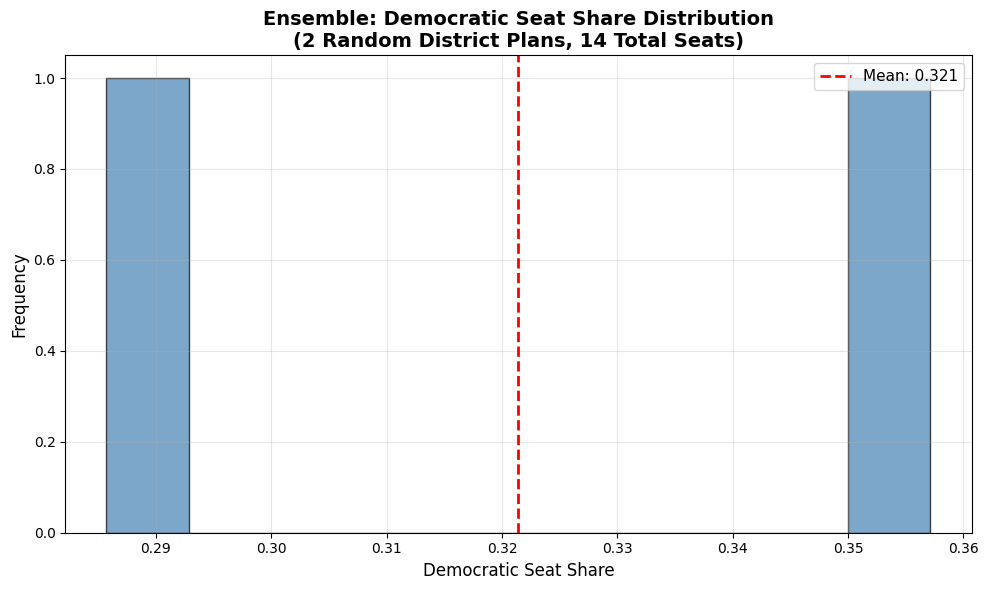

In [17]:
save_results_for_run(ensemble)

📈 BASELINE RESULTS VISUALIZATION

📂 Loading results from: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/baseline_ensemble.csv
✅ Loaded 2 plans

📊 Summary Statistics:
   Number of plans: 2
   Total seats per plan: 14
   Democratic seats:
      Mean:   4.50
      Median: 4
      Min:    4
      Max:    5
      Std:    0.71

🎨 Creating histogram...
✅ Saved histogram to: /Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Outputs/democratic_seats.png

🗳️  Democratic Seat Share:
   Mean:   0.321 (32.1%)
   Min:    0.286 (28.6%)
   Max:    0.357 (35.7%)

✅ Visualization complete


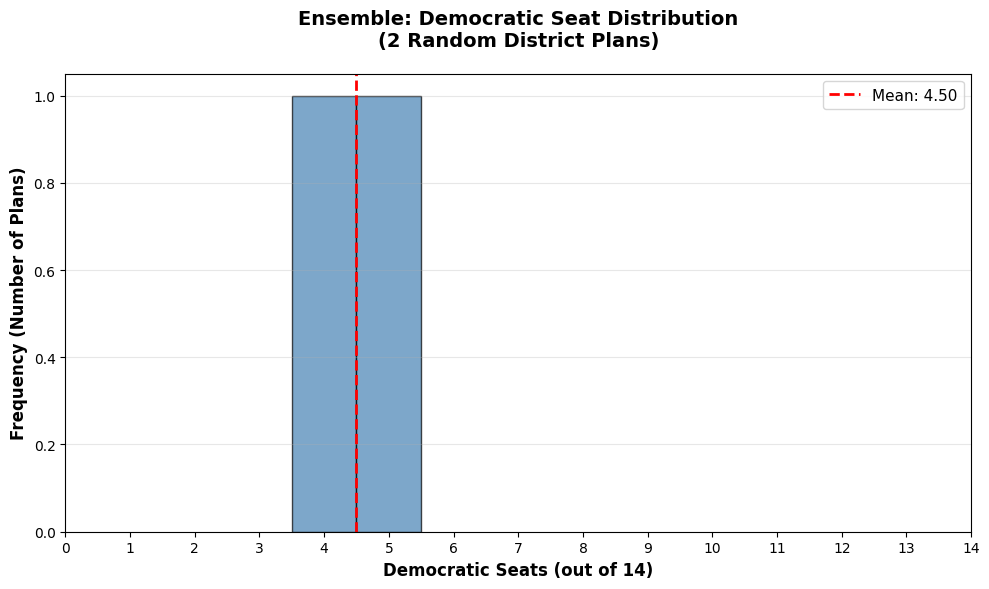

In [18]:
plot_results_for_run()

#### Deprecated district contiguity check

In [19]:
# # Check contiguity per district (graph-based)
# def load_plan_assignment(plan_id, plans_dir):
#     """Load district assignment for a specific plan."""
#     assignment_path = plans_dir / f"plan_{plan_id}.json"
# 
#     if not assignment_path.exists():
#         return None
# 
#     with open(assignment_path, 'r') as f:
#         assignment = json.load(f)
# 
#     return assignment
#
# PLAN_ID = 40
# assignment = load_plan_assignment(PLAN_ID, plans_dir)
# if not assignment:
#     print(f"Could not load assignment for Plan {PLAN_ID}")
#     sys.exit(1)
#     
# district_nodes = defaultdict(list)
# for n, d in assignment.items():
#     district_nodes[d].append(n)
# 
# def is_connected(nodes):
#     nodes = set(nodes)
#     start = next(iter(nodes))
#     q = deque([start])
#     seen = {start}
#     while q:
#         u = q.popleft()
#         for v in graph.neighbors(u):
#             if v in nodes and v not in seen:
#                 seen.add(v)
#                 q.append(v)
#     return len(seen) == len(nodes)
# 
# bad = [d for d, nodes in district_nodes.items() if not is_connected(nodes)]
# print("Non-contiguous districts:", bad)

## <span style="color:red"> Streamlit Run Command </span>
#### This line will run continually from streamlit start until streamlit end. Be sure to stop the execution of this line when you want to stop streaming the dashboard. After wards the next and final cell should run, which clears the <code>outputs</code> directory. If the directory doesn't get removed, delete it yourself to ensure a clean environment for

In [ ]:
!streamlit run "../Client/baseline_dashboard.py"


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.24.196.55:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
/Users/fuzi_x_muzi/Documents/PoliTech Research/Politech-Fair-Representation-Act/MMD_Generation_Layer/Client/baseline_dashboard.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", NUM_DISTRICTS)
2026-05-08 12:19:01.203 Serialization of dataframe to Arrow table was unsuccessful. Applying automatic fixes for column types to make the dataframe Arrow-compatible.
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/streamlit/dataframe_util.py", line 839, in convert_

#### Removes <code>outputs</code> directory for cleanup

In [ ]:
cleanup_outputs_for_run()